<a href="https://colab.research.google.com/github/SangeetBarkataki10/CS105Minproject-SSTMA/blob/main/SSTMA_CS105.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ETL Pipeline

In [1]:
import pandas as pd

df = pd.read_csv("CS105_data.csv")

column_mapping = {
    # Demographics
    2: "Class Standing",
    13: "Cumulative GPA",

    # AI Reliance
    42: "LLM Frequency (ChatGPT)",
    43: "LLM Frequency (Claude)",
    44: "LLM Frequency (Gemini)",
    46: "LLM Frequency (Copilot)",
    47: "LLM Frequency (Perplexity)",
    48: "LLM Frequency (Deepseek)",
    86: "Math Usage",
    88: "CS Usage",
    89: "Data Science Usage",
    99: "AI Chatbot Usage",

    # Confidence in Original Work
    53: "Coding Self Confidence",
    54: "Research Self Confidence",
    55: "Data Analysis Self Confidence",
    56: "Writing Self Confidence",
    57: "Topic Summarization Self Confidence",
    107: "Agreement",
    62: "Overreliance Concern",
    59: "Loss of Learning Concern",

    # Trust in AI vs Need for Verification
    92: "Math Trust",
    94: "CS Trust",
    95: "Data Science Trust",
    61: "Hallucinations/Wrong Answers"
}

columns_to_keep = list(column_mapping.keys())
df_clean = df.iloc[:, columns_to_keep].copy()

rename_dict = {df.columns[i]: new_name for i, new_name in column_mapping.items()}
df_clean = df_clean.rename(columns=rename_dict)
df_clean.dropna(inplace=True)

df_clean.to_csv("CS105_data_clean.csv", index=False)

df_clean.head()

,Class Standing,Cumulative GPA,LLM Frequency (ChatGPT),LLM Frequency (Claude),LLM Frequency (Gemini),LLM Frequency (Copilot),LLM Frequency (Perplexity),LLM Frequency (Deepseek),Math Usage,CS Usage,...,Data Analysis Self Confidence,Writing Self Confidence,Topic Summarization Self Confidence,Agreement,Overreliance Concern,Loss of Learning Concern,Math Trust,CS Trust,Data Science Trust,Hallucinations/Wrong Answers
0,Senior,3.33 – 3.67,Use Frequently,Never Used,Used 1-2 times,Never Used,Never Used,Never Used,2.0,1.0,...,Fairly Confident,Very Confident,Very Confident,4.0,4 (Moderately influential),5 (Extremely influential),2.0,2.0,2.0,4 (Moderately influential)
1,Junior,3.67 – 4.0,Use Rarely,Never Used,Use Rarely,Use Rarely,Never Used,Never Used,2.0,3.0,...,Fairly Confident,Very Confident,Very Confident,1.0,5 (Extremely influential),4 (Moderately influential),4.0,4.0,4.0,3 (Partially Influential)
2,Junior,3.33 – 3.67,Use Frequently,Use Frequently,Use Rarely,Never Used,Never Used,Never Used,2.0,2.0,...,Somewhat Confident,Fairly Confident,Fairly Confident,2.0,3 (Partially Influential),2 (Somewhat influential),1.0,2.0,1.0,2 (Somewhat influential)
3,Senior,3.33 – 3.67,Use Frequently,Use Frequently,Used 1-2 times,Use Rarely,Never Used,Never Used,0.0,4.0,...,Somewhat Confident,Very Confident,Very Confident,5.0,5 (Extremely influential),5 (Extremely influential),5.0,5.0,0.0,2 (Somewhat influential)
4,Junior,3.33 – 3.67,Use Frequently,Never Used,Use Frequently,Use Frequently,Never Used,Use Rarely,2.0,2.0,...,Somewhat Confident,Somewhat Confident,Somewhat Confident,2.0,5 (Extremely influential),4 (Moderately influential),5.0,5.0,5.0,4 (Moderately influential)


# Heatmap Pearson Correlation

The goal of this visualization is to examine whether there is a linear relationship between how frequently students use AI for coursework and their self-reported confidence in completing tasks without AI. By including concern variables like overreliance and loss of learning, we also want to see whether students who use AI more are more or less worried about depending on it. The heatmap allows us to see all these relationships at once and identify which pairs of variables are most strongly associated.

                            CS Usage  AI Chatbot Usage  ChatGPT Frequency  \
CS Usage                        1.00              0.67               0.21   
AI Chatbot Usage                0.67              1.00               0.32   
ChatGPT Frequency               0.21              0.32               1.00   
Agreement (AI ≠ interfere)      0.30              0.31               0.15   
Overreliance Concern           -0.09             -0.09               0.01   
Loss of Learning               -0.16             -0.14              -0.05   
Coding Confidence              -0.13             -0.09              -0.16   
Research Confidence            -0.18             -0.09              -0.13   
Data Analysis Confidence       -0.17             -0.09              -0.20   
Writing Confidence             -0.12             -0.01              -0.13   
Summarization Confidence       -0.16             -0.08              -0.12   

                            Agreement (AI ≠ interfere)  Overreliance Concer

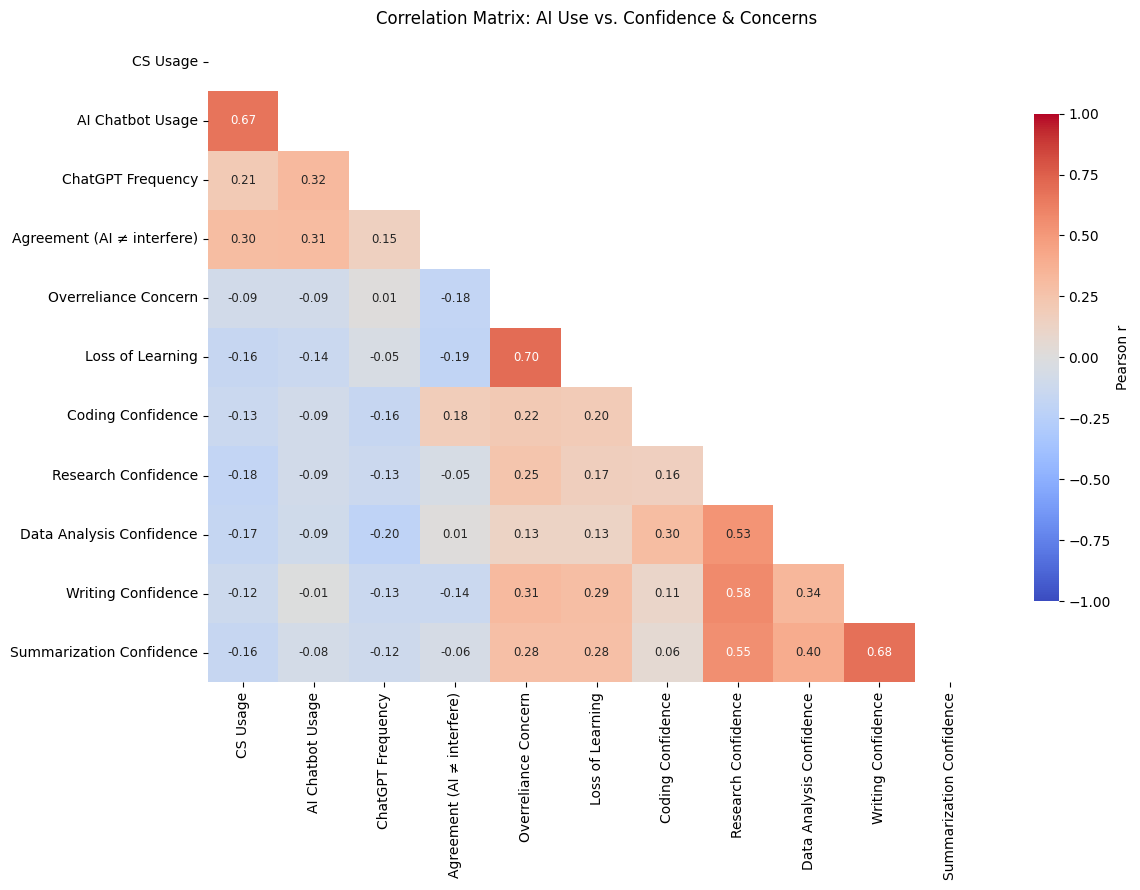

In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("CS105_data_clean.csv")

conf_map = {'Slightly Confident': 1, 'Somewhat Confident': 2, 'Fairly Confident': 3,
            'Mostly Confident': 4, 'Very Confident': 5}
concern_map = {
    "1 (Not at all/haven't thought about it)": 1,
    '2 (Somewhat influential)': 2,
    '3 (Partially Influential)': 3,
    '4 (Moderately influential)': 4,
    '5 (Extremely influential)': 5
}
llm_map = {'Never Used': 0, 'Used 1-2 times': 1, 'Use Rarely': 2, 'Use Frequently': 3}

for col, new in [('Coding Self Confidence','Coding Confidence'),
                 ('Research Self Confidence','Research Confidence'),
                 ('Data Analysis Self Confidence','Data Analysis Confidence'),
                 ('Writing Self Confidence','Writing Confidence'),
                 ('Topic Summarization Self Confidence','Summarization Confidence')]:
    df[new] = df[col].map(conf_map)

df['Overreliance Concern (num)'] = df['Overreliance Concern'].map(concern_map)
df['Loss of Learning (num)'] = df['Loss of Learning Concern'].map(concern_map)
df['ChatGPT Frequency'] = df['LLM Frequency (ChatGPT)'].map(llm_map)

corr_vars = {
    'CS Usage': 'CS Usage',
    'AI Chatbot Usage': 'AI Chatbot Usage',
    'ChatGPT Frequency': 'ChatGPT Frequency',
    'Agreement (AI ≠ interfere)': 'Agreement',
    'Overreliance Concern': 'Overreliance Concern (num)',
    'Loss of Learning': 'Loss of Learning (num)',
    'Coding Confidence': 'Coding Confidence',
    'Research Confidence': 'Research Confidence',
    'Data Analysis Confidence': 'Data Analysis Confidence',
    'Writing Confidence': 'Writing Confidence',
    'Summarization Confidence': 'Summarization Confidence',
}

corr_df = df[[v for v in corr_vars.values()]].copy()
corr_df.columns = list(corr_vars.keys())
corr_matrix = corr_df.corr(method='pearson')
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

print(corr_matrix.round(2))

fig, ax = plt.subplots(figsize=(12, 9))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, vmin=-1, vmax=1,
            annot_kws={'size': 8.5}, ax=ax, cbar_kws={'shrink': 0.75, 'label': 'Pearson r'})

ax.set_title('Correlation Matrix: AI Use vs. Confidence & Concerns')
plt.tight_layout()
plt.show()

This heat map reveals 3 relations that are havily related, and some other ones that are still correlated. Take for example CS Usage and AI Chatbot Usage, students who heavily use AI for CS related work go to chatbots when they get stuck. This shows that students will just use AI to complete tasks rather than learning and working through it with outside help. Another importnat one is overreliance vs loss of learning. Those who fear the loss of learning with AI also fear overreliance on chatbots. This shows that the people who think about AI's downsides think about it form all angles. Another strong correlation is the confidence in writing summaries and writing. Those confident in writing are also confident in summarizing without AI. This makes sense since both are similar by nature. Some other correlations likes confidence in research and writing confidence are high correlation values, but again this is expected since they are similar by nature. anothe rnotable trend is that all the columns relating confidence to CS Usage are negative. This shows that overall, heavy AI usage for CS relates to lower confidence in all fields of study, not just coding. Likewise, those who are concerned about overreliance have psotiive correaltions with all confidence fields, as they tend to rely on their own ability rather than the use of AI because they are scared of the overreliance of it. 

# Average confidence level vs AI usage

This table should try to figure out what kind of trend there is reagarding the varying levels of AI usage and the average confidence of the student. We are predicting that the higher the usage, the lower the confidence in one's own abilities. 

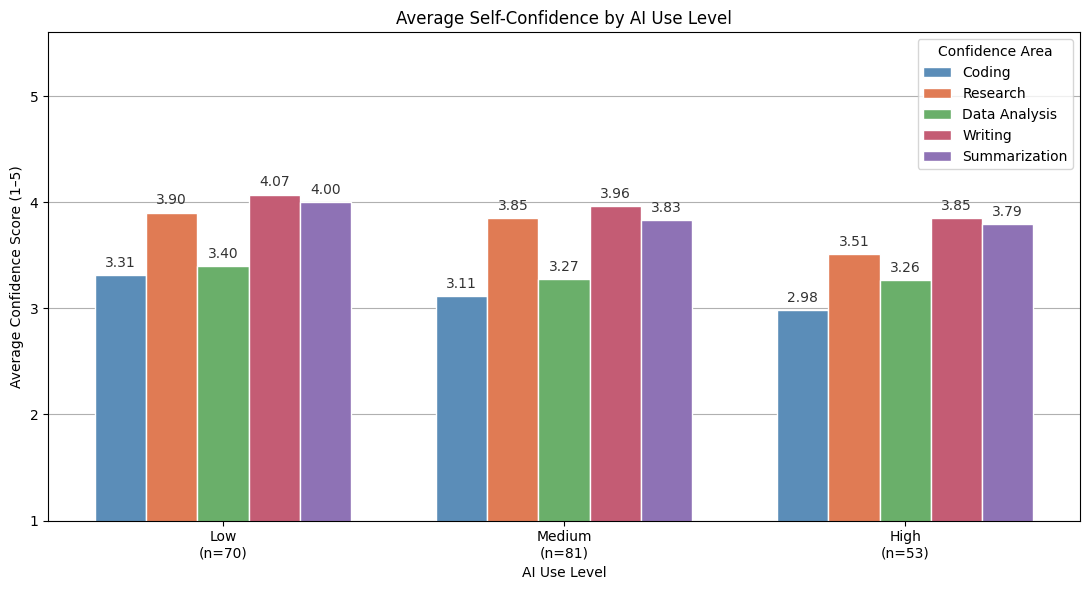

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("CS105_data_clean.csv")

conf_map = {'Slightly Confident': 1, 'Somewhat Confident': 2, 'Fairly Confident': 3,
            'Mostly Confident': 4, 'Very Confident': 5}

for col, new in [('Coding Self Confidence','Coding'),
                 ('Research Self Confidence','Research'),
                 ('Data Analysis Self Confidence','Data Analysis'),
                 ('Writing Self Confidence','Writing'),
                 ('Topic Summarization Self Confidence','Summarization')]:
    df[new] = df[col].map(conf_map)

df['AI_Use_Score'] = df[['CS Usage','Math Usage','Data Science Usage','AI Chatbot Usage']].mean(axis=1)

def ai_group(s):
    if s <= 2: return 'Low'
    elif s <= 3.5: return 'Medium'
    else: return 'High'

df['AI_Use_Level'] = df['AI_Use_Score'].apply(ai_group)

group_order = ['Low', 'Medium', 'High']
conf_cols = ['Coding', 'Research', 'Data Analysis', 'Writing', 'Summarization']
means = df.groupby('AI_Use_Level')[conf_cols].mean().reindex(group_order)
counts = df['AI_Use_Level'].value_counts().reindex(group_order)

x = np.arange(len(group_order))
width = 0.15
colors = ['#5B8DB8', '#E07B54', '#6AAF6A', '#C45C74', '#8E72B5']

fig, ax = plt.subplots(figsize=(11, 6))

for i, col in enumerate(conf_cols):
    offset = (i - len(conf_cols)/2 + 0.5) * width
    bars = ax.bar(x + offset, means[col], width, label=col,
                  color=colors[i], edgecolor='white')
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
                f'{bar.get_height():.2f}', ha='center', va='bottom', color='#333333')

ax.set_xticks(x)
ax.set_xticklabels([f'{g}\n(n={counts[g]})' for g in group_order])
ax.set_xlabel('AI Use Level')
ax.set_ylabel('Average Confidence Score (1–5)')
ax.set_title('Average Self-Confidence by AI Use Level')
ax.set_ylim(1, 5.6)
ax.grid(axis='y')
ax.set_axisbelow(True)
ax.legend(title='Confidence Area')
plt.tight_layout()
plt.show()

As we can see, the averages for the confidence values drop as you go higher in the AI usage level. This is consistent for every single confidence level. Low AI usage has the highest values for each confidence level, while the high AI usage has the lowest values. This means that our hypothesis is true and students lose their confidence in themselves as they rely and use AI more and more. 